In [1]:
""""
Summarize fuel treatment acres within fire perimeters
Maxwell.Cook@colostate.edu
"""

# imports
import os, sys

# import the __functions.py (custom functions)
sys.path.append(os.getcwd()) # add code folder to system path
from __functions import *  # imports all custom functions

# local data directories
datadir = '/Users/mcc/Library/CloudStorage/Box-Box/MCC/data/'
projdir = os.path.dirname(os.getcwd())
print(projdir)

print("Ready !")

/Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/valuation
Ready !


In [2]:
# load the incidents / perimeters
mtbs = os.path.join(projdir, 'data/spatial/wf_incidents_2014_2022_mtbs_perims.gpkg')
mtbs = gpd.read_file(mtbs)
print(f"Processing for {len(mtbs)} fires.")
print(f"CRS: {mtbs.crs}")
# clean the dataframe just a bit for processing
mtbs = mtbs[['Event_ID','Incid_Name','Ig_Date','BurnBndAc','geometry']]
mtbs.head()

Processing for 3494 fires.
CRS: EPSG:4326


,Event_ID,Incid_Name,Ig_Date,BurnBndAc,geometry
0,NJ3973407472120220619,MULLICA RIVER FIRE,6/19/22 0:00,13082,"MULTIPOLYGON (((-74.69252 39.68403, -74.6923 3..."
1,NC3565607641720220619,FEREBEE ROAD,6/19/22 0:00,1954,"MULTIPOLYGON (((-76.42425 35.65565, -76.42447 ..."
2,FL2576508042220220329,137 AVE,3/29/22 0:00,857,"MULTIPOLYGON (((-80.43589 25.77237, -80.43507 ..."
3,FL2632608099820220328,INTERCEPTOR,3/28/22 0:00,4143,"MULTIPOLYGON (((-81.08343 26.29129, -81.08347 ..."
4,MS3143909088120220304,HWY 556 - BUDE MS,3/4/22 0:00,663,"MULTIPOLYGON (((-90.87669 31.45572, -90.87648 ..."


In [3]:
# load the fuel treatment data
fp = os.path.join(projdir, 'data/spatial/treatments/twig_treatments_1km.gpkg')
trts = gpd.read_file(fp)
print(f"Columns:\n{trts.columns}")
print(f"CRS: {trts.crs}")
trts[['Event_ID', 'unique_id', 'treatment_date', 'actual_completion_date', 'type', 'acres']].head()

Columns:
Index(['type', 'date_source', 'identifier_database', 'fund_source', 'state',
       'SHAPE__Area', 'unique_id', 'actual_completion_date', 'agency',
       'date_current', 'twig_category', 'treatment_date', 'name', 'acres',
       'category', 'SHAPE__Length', 'objectid', 'index_right', 'Event_ID',
       'Fire_Name', 'activity', 'total_cost', 'cost_per_uom', 'fund_code',
       'uom', 'method', 'equipment', 'activity_code', 'error', 'geometry'],
      dtype='object')
CRS: EPSG:3857


,Event_ID,unique_id,treatment_date,actual_completion_date,type,acres
0,NC3565607641720220619,126344-6325503,1631750400000,1.631750e+12,Mastication,961.308524
1,NC3565607641720220619,126342-6325503,1631750400000,1.631750e+12,Mastication,961.308524
2,NC3565607641720220619,126343-6325503,1631750400000,1.631750e+12,Mastication,961.308524
3,NC3565607641720220619,137998-6325504,1659312000000,1.659312e+12,Mowing,961.308524
4,NC3565607641720220619,138000-6325504,1659312000000,1.659312e+12,Mowing,961.308524


In [4]:
# handle duplicate records
# obvious ones first
N = len(trts)
trts = trts.drop_duplicates(subset=['Event_ID', 'treatment_date', 'actual_completion_date', 'type', 'acres', 'geometry'])
print(f"Dropped {N - len(trts)} duplicate records.")

Dropped 12539 duplicate records.


In [5]:
# crop treatments to the fire perimeters
# buffer perimeters 1km
print("Buffering fire perimeters ...")
buffer = mtbs.copy().to_crs('EPSG:5070') # make sure we're in meters for the buffer
buffer['geometry'] = buffer.geometry.buffer(1000)
buffer = buffer.to_crs(trts.crs) # now match the treatment CRS

trt_clips = [] # to store the results
for idx, fire_row in tqdm(buffer.iterrows(), total=buffer.shape[0], desc='Processing Fires'):
    fire_id = fire_row['Event_ID']
    fire_geom = fire_row['geometry']

    # select overlapping treatments
    candidates = trts[trts.intersects(fire_geom)]

    if not candidates.empty:
        # Clip treatments to this fire buffer
        clipped = gpd.clip(candidates, fire_geom)
        clipped['Event_ID'] = fire_id  # Track which fire this treatment is from
        trt_clips.append(clipped)
        del clipped
    del candidates

# Combine all clipped results into one GeoDataFrame
if trt_clips:
    trts_fire = gpd.GeoDataFrame(pd.concat(trt_clips, ignore_index=True), crs=trts.crs)
else:
    trts_fire = gpd.GeoDataFrame()
del trt_clips

# Recalculate area
trts_fire['gis_acres'] = trts_fire.geometry.area / 4046.86
trts_fire.head()

Buffering fire perimeters ...


Processing Fires:   0%|          | 0/3494 [00:00<?, ?it/s]

,type,date_source,identifier_database,fund_source,state,SHAPE__Area,unique_id,actual_completion_date,agency,date_current,...,total_cost,cost_per_uom,fund_code,uom,method,equipment,activity_code,error,geometry,gis_acres
0,Mastication,act_comp_dt,NFPORS,No Funding Code,NC,3.769421e+06,144542-6325505,1.691712e+12,FWS,1.698775e+12,...,NaN,NaN,None,None,None,None,None,None,"MULTIPOLYGON (((-8508218.776 4260282.051, -850...",5.441002
1,Mastication,act_comp_dt,NFPORS,No Funding Code,NC,5.914354e+06,126344-6325503,1.631750e+12,FWS,1.634591e+12,...,NaN,NaN,None,None,None,None,None,None,"MULTIPOLYGON (((-8508228.915 4260289.081, -850...",14.253051
2,Mowing,act_comp_dt,NFPORS,No Funding Code,NC,5.914354e+06,137998-6325504,1.659312e+12,FWS,1.669761e+12,...,NaN,NaN,None,None,None,None,None,None,"MULTIPOLYGON (((-8508228.915 4260289.081, -850...",14.253051
3,Broadcast Burn,act_comp_dt,NFPORS,No Funding Code,FL,7.562210e+06,124458-6327377,1.613779e+12,BIA,1.633944e+12,...,NaN,NaN,None,None,None,None,None,None,"POLYGON ((-9025720.879 3033185.453, -9025430.0...",567.509222
4,Broadcast Burn,act_comp_dt,NFPORS,No Funding Code,FL,7.562210e+06,124458-6327377,1.613779e+12,BIA,1.633944e+12,...,NaN,NaN,None,None,None,None,None,None,"POLYGON ((-9025720.879 3033185.453, -9025430.0...",567.509222


In [6]:
trts_fire.columns

Index(['type', 'date_source', 'identifier_database', 'fund_source', 'state',
       'SHAPE__Area', 'unique_id', 'actual_completion_date', 'agency',
       'date_current', 'twig_category', 'treatment_date', 'name', 'acres',
       'category', 'SHAPE__Length', 'objectid', 'index_right', 'Event_ID',
       'Fire_Name', 'activity', 'total_cost', 'cost_per_uom', 'fund_code',
       'uom', 'method', 'equipment', 'activity_code', 'error', 'geometry',
       'gis_acres'],
      dtype='object')

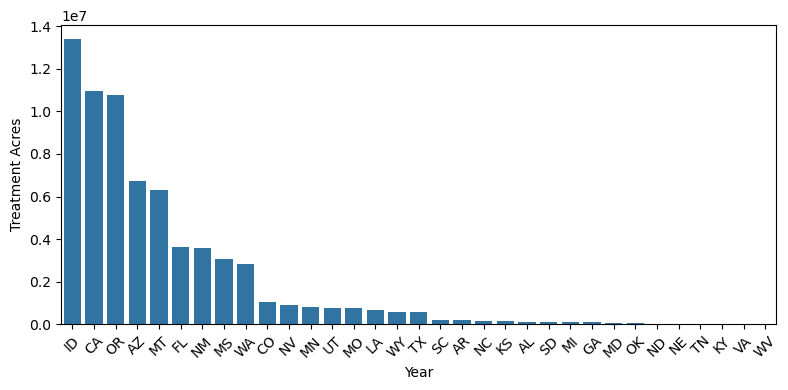

In [7]:
# make some plots.
# treatment area by state/year
trt_state_sum = trts_fire.groupby(['state']).agg(
    treatment_acres = ('gis_acres', 'sum')
).reset_index()
trt_state_sum = trt_state_sum.sort_values(by='treatment_acres', ascending=False)

# plot it
plt.figure(figsize=(8,4))
sns.barplot(data=trt_state_sum, x='state', y='treatment_acres')
plt.xlabel('Year')
plt.ylabel('Treatment Acres')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# calculate the treatment percentage of fire area
trt_pct = trts_fire.groupby(['Event_ID']).agg(
    treated_acres_c = ('gis_acres', 'sum'), # sum of overlapping treatment acres
    total_treatment_cost = ('total_cost', 'sum'), # sum of treatment costs where available
    unique_treatments = ('unique_id', 'nunique') # number of unique treatments intersecting the fire
).reset_index()

# join in the fire acres
trt_pct = trt_pct.merge(mtbs[['Event_ID','BurnBndAc']], on="Event_ID")

# calculate the proportion of burned area treated
trt_pct['treated_prop_c'] = trt_pct['treated_acres_c'] / trt_pct['BurnBndAc'] * 100
trt_pct.drop(columns=['BurnBndAc'], inplace=True)
trt_pct = trt_pct[['Event_ID', 'treated_acres_c', 'treated_prop_c', 'total_treatment_cost', 'unique_treatments']]
# check it
trt_pct.head()

,Event_ID,treated_acres_c,treated_prop_c,total_treatment_cost,unique_treatments
0,AL3267208704520220215,23746.416093,899.144873,7.659044e+05,32
1,AL3274708707120221010,3328.520938,626.840101,1.879058e+05,10
2,AL3277908693520190402,24943.002106,2073.400009,1.050922e+06,110
3,AL3317108611720161113,5742.824769,550.606402,4.377022e+05,97
4,AL3326608609720161012,16591.496538,2633.570879,7.476158e+05,109


In [10]:
# make a dissolved version to get total fire proportion treated
# (independent of overlapping treatments)
trt_total = trts_fire.dissolve(by='Event_ID')
trt_total['treated_acres_d'] = trt_total.geometry.area / 4046.86

# calculate the treatment percentage of fire area
buffer['fire_buffer_acres'] = buffer.geometry.area / 4046.86 # recalculate mtbs acres with buffer
trt_prop = trt_total.merge(buffer[['Event_ID','fire_buffer_acres']], on="Event_ID")
trt_prop['treated_prop_d'] = trt_prop['gis_acres'] / trt_prop['fire_buffer_acres'] * 100
trt_prop = trt_prop[['Event_ID','treated_prop_d','treated_acres_d','fire_buffer_acres']]

# merge the two summaries
treated_summary = pd.merge(trt_pct, trt_prop, on='Event_ID')
treated_summary.head()

,Event_ID,treated_acres_c,treated_prop_c,total_treatment_cost,unique_treatments,treated_prop_d,treated_acres_d,fire_buffer_acres
0,AL3267208704520220215,23746.416093,899.144873,7.659044e+05,32,3.591633,7340.110244,9898.875813
1,AL3274708707120221010,3328.520938,626.840101,1.879058e+05,10,11.640832,2073.199737,4685.799019
2,AL3277908693520190402,24943.002106,2073.400009,1.050922e+06,110,17.090480,7039.355641,8453.127006
3,AL3317108611720161113,5742.824769,550.606402,4.377022e+05,97,0.348906,1045.511391,6247.784127
4,AL3326608609720161012,16591.496538,2633.570879,7.476158e+05,109,0.484299,3665.991893,5377.287966


In [11]:
print(f"{len(treated_summary)} fires with intersecting treatments.")
print(f"Total of {len(trts_fire)} treatments.")

1694 fires with intersecting treatments.
Total of 178465 treatments.


In [12]:
# save out.
# table:
out_fp = os.path.join(projdir, 'data/tabular/MTBS_TWIG_summary.csv')
treated_summary.to_csv(out_fp, index=False)
print(f"Saved summary table to: {out_fp}")
# spatial (all):
out_fp = os.path.join(projdir, 'data/spatial/MTBS_TWIG_intersection.gpkg')
trts_fire.to_file(out_fp)
print(f"Saved spatial data to: {out_fp}")

Saved summary table to: /Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/valuation/data/tabular/MTBS_TWIG_summary.csv
Saved spatial data to: /Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/valuation/data/spatial/MTBS_TWIG_intersection.gpkg
